# Convolutional Neural Networks for Sentence Classification

_This notebook demonstrates the implementation of Convolutional Neural Networks for Sentence Classification proposed by [Kim, 2014](https://arxiv.org/pdf/1408.5882.pdf)._


Traditionally, Convolutional Neural Networks (CNNs) were invented for computed vision and achieved state-of-the-art performance in computer vision and speech recognition. CNNs act like feature extractors where they scan different regions of the image using the kernel and output of each layer is passed to the next CNN layer. The lower layers in CNNs are useful at detecting low-level features such as edges whereas the higher layers in CNNs are useful at detecting facial features such as eyes, nose, ear, etc.

The above paper proposed by [Kim, 2014](https://arxiv.org/pdf/1408.5882.pdf) was one of the earliest work demonstrating the applications of CNNs in NLP tasks, specifically text classification. In this case, CNN is used as a feature extractor which encodes semantic features of text and then these features are fed into classifier.

RNNs extract the prefix sequence features which might not be always helpful as preserving complete context is very difficult for longer sequences and we may get wrong prediction. CNNs help us to extract subsequence features which are beneficial for classification tasks as the dominant features context would be preserved.

We will build a CNN based sentiment classifier for IMDB movie reviews.


### Why CNN Works for Text Classification

In text classification, the goal is not to model the entire sequence in a strictly sequential manner, but rather to identify the most informative local patterns that strongly correlate with a class label. CNNs are particularly effective for this because they apply convolutional filters over local word windows (n-grams), enabling automatic extraction of meaningful phrases such as:

- "very good"
- "not worth watching"
- "absolutely fantastic performance"

Each convolutional filter acts as a detector for a specific linguistic pattern. When a filter strongly activates at a certain position in the text, it indicates the presence of a feature that may contribute to the final classification.

Unlike traditional bag-of-words approaches, CNNs preserve word order within the local window, allowing the model to distinguish between phrases such as:

- "not good"
- "good"

which would otherwise share the same words but have completely different sentiment.

---

### Convolution Operation in Text

Given an embedded sentence representation:

$$
x_{emb} \in \mathbb{R}^{L \times d}
$$

where:
- $L$ is sequence length
- $d$ is embedding dimension

A convolutional filter of width $k$ slides across $k$ consecutive words and computes:

$$
c_i = f(W \cdot x_{i:i+k-1} + b)
$$

where:
- $W$ is the filter weight matrix
- $b$ is bias
- $f$ is a non-linear activation (ReLU)

This produces a feature map that highlights important subsequences.

---

### Role of Max-Pooling

After convolution, max-pooling is applied across time:

$$
\hat{c} = \max(c)
$$

This operation selects the most dominant feature detected by each filter across the entire sentence. It introduces:

- Position invariance (important phrase can occur anywhere)
- Dimensionality reduction
- Strong signal compression

Thus, the model focuses only on the most important evidence for classification.

---

### Advantages of CNNs for Text

- Parallel computation (faster than RNNs)
- Fewer parameters compared to deep recurrent models
- Strong local feature extraction capability
- Robust to varying sentence lengths
- Effective even with limited training data

---

### Comparison with RNN-based Models

While RNNs (LSTM/GRU) attempt to model long-range dependencies by sequentially processing tokens, they may struggle with:

- Vanishing gradients
- Difficulty in capturing very long dependencies
- Slower training due to sequential computation

CNNs, in contrast:

- Capture discriminative local patterns efficiently
- Allow deeper stacking without sequential bottlenecks
- Focus on phrase-level semantics rather than full sequence memorization

For sentiment classification tasks such as IMDB reviews, sentiment polarity often depends on short but strong phrases rather than entire document structure, making CNNs highly suitable.

---

### Model Objective

For binary sentiment classification (positive vs negative), the final output logits are passed through a sigmoid or softmax function:

$$
\hat{y} = \text{softmax}(Wx + b)
$$

The model is trained using Cross Entropy Loss to minimize prediction error:

$$
\mathcal{L} = -\sum y \log(\hat{y})
$$

The network learns to adjust filter weights such that sentiment-indicative phrases activate strongly for the correct class.

---

In this implementation, we leverage pre-trained word embeddings (GloVe) to initialize the embedding layer, allowing the model to start with semantically meaningful representations. These embeddings help improve generalization, especially when training data is limited.

Overall, CNN-based text classification provides a computationally efficient and highly effective approach for sentiment analysis on datasets such as IMDB movie reviews.


In [1]:
%pip install torch==2.4.1+cu121 datasets transformers tokenizer scikit-learn matplotlib seaborn --extra-index-url https://download.pytorch.org/whl/cu121 -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 798.9/798.9 MB 2.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.7/23.7 MB 81.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 823.6/823.6 kB 48.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.1/14.1 MB 102.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 410.6/410.6 MB 1.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 121.6/121.6 MB 15.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.5/56.5 MB 35.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 124.2/124.2 MB 15.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 196.0/196.0 MB 9.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 176.2/176.2 MB 10.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.1/99.1 kB 8.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━

In [2]:
%%capture
!python -m spacy download en -q
!python -m pip install spacy -q
!python -m spacy download en_core_web -q

In [3]:
import random
import numpy as np
import os
import zipfile
from typing import List,Tuple
from collections import Counter

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset

from datasets import load_dataset
import spacy
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

import urllib.request
import zipfile
from sklearn.metrics import classification_report
from transformers import AutoTokenizer
import json
import warnings
from tqdm.notebook import tqdm
warnings.filterwarnings('ignore')

## Load Spacy Tokenizer

In [4]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)
torch.backends.cudnn.deterministic = True

## Check Cuda availability

In [5]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

## *Data Preprocessing and Loading*

In [6]:
print('Loading spacy tokenizer...')
try:
    nlp = spacy.load('en_core_web_sm')
    def tokenize(text):
        return [tok.text.lower() for tok in nlp.tokenizer(text)]
except Exception as e:
    print(f'Spacy not available: {e}')
    print('Using simple whitespace tokenizer')
    def tokenize(text):
        return text.lower().split()

Loading spacy tokenizer...


## Custom Vocabulary Class

In [7]:
class Vocabulary:
    PAD_TOKEN = '<pad>'
    UNK_TOKEN = '<unk>'

    def __init__(self,max_size=25000):
        self.max_size = max_size
        self.word2idx = {}
        self.idx2word = {}
        self.word_freq = Counter()
        self.word2idx[self.PAD_TOKEN] = 0
        self.word2idx[self.UNK_TOKEN] = 1
        self.idx2word[0] = self.PAD_TOKEN
        self.idx2word[1] = self.UNK_TOKEN
    def build(self,texts):
        print(f'\n Building Vocabulary From {len(texts)} texts...')
        for text in tqdm(texts, desc='Tokenizing'):
            tokens = tokenize(text)
            self.word_freq.update(tokens)
        most_common = self.word_freq.most_common(self.max_size-2)
        for idx, (word,_) in enumerate(most_common,start=2):
            self.word2idx[word] = idx
            self.idx2word[idx] = word
        print(f'Vocabulary Size : {len(self.word2idx):,}')
    def encode(self,tokens):
        return [self.word2idx.get(token,self.word2idx[self.UNK_TOKEN]) for token in tokens]

    @property
    def pad_idx(self):
        return self.word2idx[self.PAD_TOKEN]
    @property
    def unk_idx(self):
        return self.word2idx[self.UNK_TOKEN]
    def __len__(self):
        return len(self.word2idx)

## Load IMDB Data Set

In [8]:
print('\n Loading IMDB Dataset \n')

imdb = load_dataset('imdb')
#Spliting Criteria 7:3
train_val = imdb['train'].train_test_split(test_size=0.3,seed=42)
train_texts = train_val['train']['text']
valid_texts = train_val['test']['text']
test_texts = imdb['test']['text']

train_labels = train_val['train']['label']
valid_labels = train_val['test']['label']
test_labels = imdb['test']['label']

print(f'# of training examples: {len(train_texts)}')
print(f'# of validation examples: {len(valid_texts)}')
print(f'# of testing examples: {len(test_texts)}')

# Build vocabulary with max size 25002 (25000 vocab size 2 is unk,pad token)
vocab = Vocabulary(max_size=25002)
vocab.build(train_texts)


 Loading IMDB Dataset 



README.md: 0.00B [00:00, ?B/s]

plain_text/train-00000-of-00001.parquet:   0%|          | 0.00/21.0M [00:00<?, ?B/s]

plain_text/test-00000-of-00001.parquet:   0%|          | 0.00/20.5M [00:00<?, ?B/s]

plain_text/unsupervised-00000-of-00001.p(…):   0%|          | 0.00/42.0M [00:00<?, ?B/s]

...

Generating test split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating unsupervised split:   0%|          | 0/50000 [00:00<?, ? examples/s]

# of training examples: 17500
# of validation examples: 7500
# of testing examples: 25000

 Building Vocabulary From 17500 texts...


Tokenizing:   0%|          | 0/17500 [00:00<?, ?it/s]

Vocabulary Size : 25,002


In [9]:
EMBED_SIZE = 300
GLOVE_DIR = 'glove_embeddings'
GLOVE_FILE = os.path.join(GLOVE_DIR, 'glove.6B.300d.txt')

if not os.path.exists(GLOVE_FILE):
    print('\nDownloading GloVe embeddings...')
    os.makedirs(GLOVE_DIR, exist_ok=True)
    zip_path = os.path.join(GLOVE_DIR, 'glove.6B.zip')
    
    try:
        import urllib.request
        url = 'https://nlp.stanford.edu/data/glove.6B.zip'
        print(f'Downloading from {url}...')
        urllib.request.urlretrieve(url, zip_path)
        print('Download complete, extracting...')
        
        import zipfile
        with zipfile.ZipFile(zip_path, 'r') as z:
            z.extract('glove.6B.300d.txt', GLOVE_DIR)
        os.remove(zip_path)
        print('GloVe embeddings extracted successfully.')
    except Exception as e:
        print(f'GloVe download failed: {e}')
        print('Using random embeddings instead.')
        GLOVE_FILE = None

def load_glove_embeddings(glove_path, vocab, embed_dim):
    """Load GloVe vectors for words in vocabulary."""
    embedding_matrix = torch.randn(len(vocab), embed_dim)
    embedding_matrix[vocab.pad_idx] = torch.zeros(embed_dim)
    
    if glove_path is None or not os.path.exists(glove_path):
        print(f'GloVe file not found, using random embeddings')
        return embedding_matrix
    
    loaded = 0
    with open(glove_path, 'r', encoding='utf-8') as f:
        for line in tqdm(f, desc='Loading GloVe embeddings'):
            parts = line.strip().split()
            word = parts[0]
            if word in vocab.word2idx:
                try:
                    vector = torch.tensor([float(x) for x in parts[1:]])
                    if vector.shape[0] == embed_dim:
                        embedding_matrix[vocab.word2idx[word]] = vector
                        loaded += 1
                except:
                    pass
    
    print(f'Loaded {loaded:,} / {len(vocab):,} pretrained word vectors from {glove_path}')
    return embedding_matrix

pretrained_embeddings = load_glove_embeddings(GLOVE_FILE, vocab, EMBED_SIZE)


Download complete, extracting...
GloVe embeddings extracted successfully.


Loading GloVe embeddings: 0it [00:00, ?it/s]

Loaded 23,131 / 25,002 pretrained word vectors from glove_embeddings/glove.6B.300d.txt


# Dataset class for IMDB with custom vocabulary

In [10]:
class IMDBDataset(Dataset):
    def __init__(self,texts,labels,vocab,tokenizer_fn):
        self.texts = texts
        self.labels = labels
        self.vocab = vocab
        self.tokenizer_fn = tokenizer_fn
    def __len__(self):
        return len(self.texts)
    def __getitem__(self,idx):
        tokens=self.tokenizer_fn(self.texts[idx])
        token_ids = self.vocab.encode(tokens)
        label = self.labels[idx]
        return torch.tensor(token_ids,dtype=torch.long), torch.tensor(label, dtype=torch.long)

def collate_fn(batch):
    """Pad Sequences to same Length in Batch"""
    texts,labels = zip(*batch)
    max_len = max(len(text) for text in texts)
    padded = torch.zeros(len(texts), max_len, dtype=torch.long)
    for i,t in enumerate(texts):
        padded[i, :len(t)] = t
    labels = torch.stack(labels)
    return {'text':padded,'label':labels}
BATCH_SIZE = 64
train_dataset = IMDBDataset(train_texts, train_labels, vocab, tokenize)
valid_dataset = IMDBDataset(valid_texts, valid_labels, vocab, tokenize)
test_dataset = IMDBDataset(test_texts, test_labels, vocab, tokenize)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate_fn)
valid_loader = DataLoader(valid_dataset, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn)

# Display dataset statistics

In [11]:
print(f'# of training examples: {len(train_texts)}')
print(f'# of validation examples: {len(valid_texts)}')
print(f'# of testing examples: {len(test_texts)}')

print(f'\nVocabulary Info:')
print(f'Vocab size: {len(vocab):,}')
#print(f'Pad token ID: {vocab.pad_idx}')
print(f'Embedding dimension: {EMBED_SIZE}')

# of training examples: 17500
# of validation examples: 7500
# of testing examples: 25000

Vocabulary Info:
Vocab size: 25,002
Embedding dimension: 300


In [12]:
# Verify DataLoaders
print('DataLoader Summary:')
print(f'Train batches: {len(train_loader)}')
print(f'Valid batches: {len(valid_loader)}')
print(f'Test batches: {len(test_loader)}')

DataLoader Summary:
Train batches: 274
Valid batches: 118
Test batches: 391


In [13]:
# Sanity check to see DataLoader format
batch = next(iter(train_loader))
print('Batch structure:')
print(f'text shape: {batch["text"].shape}')
print(f'label shape: {batch["label"].shape}')
print(f'Sample labels: {batch["label"]}')
print(f'Max sequence length in batch: {batch["text"].shape[1]}')

Batch structure:
text shape: torch.Size([64, 949])
label shape: torch.Size([64])
Sample labels: tensor([1, 1, 1, 0, 0, 1, 1, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1, 1,
        0, 0, 0, 1, 0, 1, 1, 1, 0, 0, 1, 0, 1, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1,
        1, 0, 0, 0, 1, 1, 0, 1, 0, 1, 0, 0, 0, 1, 1, 0])
Max sequence length in batch: 949


## Model Architecture

![cnn_architecture](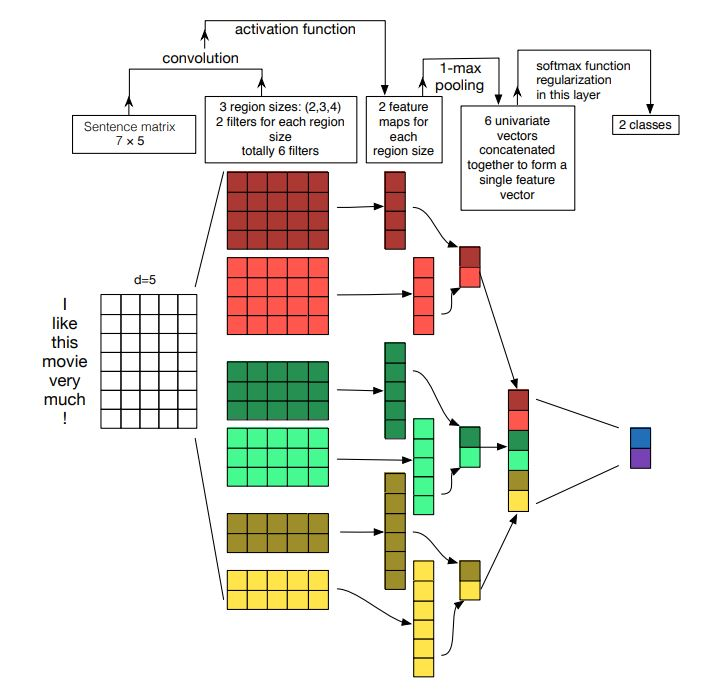 "CNN architecture for sentence classification")

(source: https://arxiv.org/pdf/1510.03820.pdf)


CNN based text classifier reads the input sequence and generates a feature representation for the subsequences which are used for classification.

For the implementation in this notebook, we first apply the embedding layer on the input sequence $x$ to obtain the embedded representation $x_{emb}$. The embedding layer maps each token in the sequence to a dense, low-dimensional continuous vector, thereby capturing semantic and syntactic relationships between words. Formally,

$$
x_{emb} = f_{embedding}(x), \quad x_{emb} \in \mathbb{R}^{L \times d}
$$

where $L$ is the sequence length and $d$ is the embedding dimension.

Next, we apply 1D convolutions of different filter sizes to obtain feature maps $x_{conv_i}$ corresponding to each filter $i$. Each filter of size $k$ slides over $k$ consecutive tokens and captures local n-gram features (e.g., bi-grams, tri-grams). If we use $n_i$ filters of size $k_i$, then:

$$
x_{conv_i} = \text{conv1D}_{k_i}(x_{emb})
$$

Each convolution operation produces a feature map of size:

$$
(L - k_i + 1) \times n_i
$$

Further, we apply ReLU activation to introduce non-linearity:

$$
x'_{conv_i} = \text{ReLU}(x_{conv_i})
$$

ReLU ensures that only positively activated features are propagated forward, improving model expressiveness and mitigating vanishing gradient issues.

We then apply max pooling over time to reduce each feature map to a single scalar per filter. This operation selects the most important feature (maximum activation) across the entire sequence for each filter:

$$
x_{pool_i} = \text{maxpool}(x'_{conv_i})
$$

Thus, each filter contributes one scalar value representing the most salient feature it has detected in the input sequence.

All pooled features are concatenated to form a single fixed-length representation:

$$
x_{concat} = [x_{pool_1}; x_{pool_2}; \dots; x_{pool_m}]
$$

where $m$ is the total number of filters across all filter sizes. This concatenated vector encodes multi-scale local features extracted from the text.

To improve generalization and reduce overfitting, dropout is applied to the concatenated representation:

$$
x_{drop} = \text{dropout}(x_{concat})
$$

Finally, a linear transformation is applied over the concatenated representation using the weight matrix $W$ and bias $b$ to compute logits:

$$
\text{logits} = W x_{drop} + b
$$

Either sigmoid or softmax is applied to these computed logits depending on the classification problem:

- **Sigmoid** for binary classification:
  $$
  \hat{y} = \sigma(\text{logits})
  $$
- **Softmax** for multi-class classification:
  $$
  \hat{y}_c = \frac{e^{\text{logits}_c}}{\sum_{j} e^{\text{logits}_j}}
  $$

The model is trained by minimizing an appropriate loss function such as Binary Cross Entropy (BCE) for binary classification or Cross Entropy Loss for multi-class classification.

Overall, the CNN based text classifier captures local contextual patterns using convolutional filters, aggregates the most informative features through max pooling, and performs classification using a fully connected output layer.


In [14]:
class CNNTextClassifier(nn.Module):
    """ 
    Simple 1D Convolutional Neural Network for Sentence Classification.
    
    """
    def __init__(self,vocab_size,n_classes,embed_size,filter_sizes,n_filters,pad_idx,dropout_rate=0.5):
        super().__init__()
        self.vocab_size = vocab_size
        self.embed_size = embed_size
        self.filter_sizes = filter_sizes
        self.n_filters = n_filters
        self.n_classes = n_classes
        self.pad_idx = pad_idx
        self.dropout_rate = dropout_rate

        self.embedding = nn.Embedding(vocab_size, embed_size, padding_idx=pad_idx)
        self.conv_list = nn.ModuleList([
            nn.Conv1d(in_channels=embed_size, out_channels=n_filters, kernel_size=filter_sizes[i])
            for i in range(len(filter_sizes))
        ])
        self.fc = nn.Linear(len(filter_sizes) * n_filters, n_classes)
        self.dropout = nn.Dropout(dropout_rate)
    def load_pretrained_embeddings(self, embeddings, fine_tune=False):
        self.embedding.weight = nn.Parameter(embeddings)
        for p in self.embedding.parameters():
            p.requires_grad = fine_tune
    def _conv_block(self,x,conv_layer):
        """
        X:(batch_size,embed_size,seq_len)
        """
        x_conv=F.relu(conv_layer(x))
        x_pool = F.max_pool1d(x_conv,kernel_size=x_conv.shape[2]).squeeze(2)
        return x_pool
    def forward(self,x):
        """
        x:(batch_szie,seq_len)
        """
        embed = self.embedding(x)
        embed=embed.permute(0,2,1)

        conv_stack = [
            self._conv_block(embed,conv) for conv in self.conv_list
        ]
        pooled_values = torch.cat(conv_stack, dim=1)  # (batch_size, sum(num_filters))      

        logits = self.fc(self.dropout(pooled_values))  # (batch_size, num_classes)

        return logits

## Model Summary fn

In [15]:
def model_summary(model):
    print(model)
    print(f'# of trainable params: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}')
    print(f'# of non-trainable params: {sum(p.numel() for p in model.parameters() if not p.requires_grad):,}')

In [16]:
def accuracy(preds, y):
    top_preds = preds.argmax(dim=1, keepdim=True)
    correct = (top_preds == y.view_as(top_preds)).sum()
    acc = correct / len(y)
    return acc

In [17]:
def train_fn(model, iterator, optimizer, criterion, device):
    model.train()
    epoch_loss = 0
    epoch_acc = 0
    
    tk0 = tqdm(iterator, total=len(iterator), position=0, leave=True,desc='Training...')

    for idx, batch in enumerate(tk0):
        text = batch['text'].to(device)
        labels = batch['label'].to(device)
        
        optimizer.zero_grad()
        logits = model(text)  # (batch_size, num_classes)
        loss = criterion(logits, labels)
        acc = accuracy(logits, labels)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)  # Gradient clipping
        optimizer.step()
        
        epoch_loss += loss.item()
        epoch_acc += acc.item()

        tk0.update(0)
    
    tk0.close()
        
    return epoch_acc / len(iterator), epoch_loss / len(iterator)

In [18]:
def eval_fn(model, iterator, criterion, device):
    model.eval()
    epoch_loss = 0
    epoch_acc = 0
    all_preds = []
    all_labels = []
    
    tk0 = tqdm(iterator, total=len(iterator), position=0, leave=True, desc='Evaluating...')

    with torch.no_grad():
        for idx, batch in enumerate(tk0):
            
            text = batch['text'].to(device)
            labels = batch['label'].to(device)
            
            logits = model(text)  # (batch_size, num_classes)
            loss = criterion(logits, labels)
            
            acc = accuracy(logits, labels)
            preds = torch.argmax(logits, dim=1).cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(labels.cpu().numpy())

            epoch_loss += loss.item()
            epoch_acc += acc.item()

            tk0.update(0)
    
    tk0.close()
    return epoch_acc / len(iterator), epoch_loss / len(iterator), all_preds, all_labels

# Hyperparameters

In [19]:
VOCAB_SIZE = len(vocab)  # Using custom vocabulary (25,002)
N_CLASSES = 2
EMBED_DIM = EMBED_SIZE
FILTER_SIZES = [3, 4, 5]
N_FILTERS = 100
PAD_IDX = vocab.pad_idx
DROPOUT_RATE = 0.5
N_EPOCHS = 16

print(f'Vocab size: {VOCAB_SIZE:,}')
print(f'Embedding dim: {EMBED_DIM}')
print(f'Filter sizes: {FILTER_SIZES}')
print(f'Number of filters: {N_FILTERS}')
print(f'Dropout rate: {DROPOUT_RATE}')

Vocab size: 25,002
Embedding dim: 300
Filter sizes: [3, 4, 5]
Number of filters: 100
Dropout rate: 0.5


In [20]:
model = CNNTextClassifier(VOCAB_SIZE, N_CLASSES, EMBED_DIM, FILTER_SIZES, N_FILTERS, PAD_IDX, DROPOUT_RATE)
print('\nLoading pretrained GloVe embeddings into model...')
model.load_pretrained_embeddings(pretrained_embeddings, fine_tune=True)
model = model.to(device)
print(f'\nModel architecture:')

print(model)
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
non_trainable_params = sum(p.numel() for p in model.parameters() if not p.requires_grad)
print(f'# of trainable params: {trainable_params:,}')
print(f'# of non-trainable params: {non_trainable_params:,}')


Loading pretrained GloVe embeddings into model...

Model architecture:
CNNTextClassifier(
  (embedding): Embedding(25002, 300, padding_idx=0)
  (conv_list): ModuleList(
    (0): Conv1d(300, 100, kernel_size=(3,), stride=(1,))
    (1): Conv1d(300, 100, kernel_size=(4,), stride=(1,))
    (2): Conv1d(300, 100, kernel_size=(5,), stride=(1,))
  )
  (fc): Linear(in_features=300, out_features=2, bias=True)
  (dropout): Dropout(p=0.5, inplace=False)
)
# of trainable params: 7,861,502
# of non-trainable params: 0


In [21]:
optimizer = optim.Adadelta(model.parameters(), lr=1e-1)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, patience=0, threshold=0.001, mode='max'
)

In [22]:
criterion = nn.CrossEntropyLoss()

In [23]:
best_acc = 0
es_patience = 3
patience = 0
model_path = 'model.pth'
train_losses, valid_losses = [], []
train_accs, valid_accs = [], []

for epoch in range(N_EPOCHS):
    train_acc, train_loss = train_fn(model, train_loader, optimizer, criterion, device)
    
    valid_acc, valid_loss, _, _ = eval_fn(model, valid_loader, criterion, device)
    
    train_losses.append(train_loss)
    valid_losses.append(valid_loss)
    train_accs.append(train_acc)
    valid_accs.append(valid_acc)
    
    print(f'✦  Epoch: {epoch+1}/{N_EPOCHS}, Train Acc: {train_acc * 100:.2f}%, Train Loss: {train_loss:.4f}, Valid Acc: {valid_acc * 100:.2f}%, Valid Loss: {valid_loss:.4f}')
    
    scheduler.step(valid_acc)

    is_best = valid_acc > best_acc
    if is_best:
        print(f'✦  Best accuracy improved ({best_acc * 100:.2f}% -> {valid_acc * 100:.2f}%). Saving Model!')
        best_acc = valid_acc
        patience = 0
        torch.save(model.state_dict(), model_path)
    else:
        patience += 1
        print(f'✦  Early stopping counter: {patience} out of {es_patience}')
        if patience == es_patience:
            print(f'✦  Early stopping! Best accuracy: {best_acc * 100:.2f}%')
            break

print('Training completed Successfully!')

Training...:   0%|          | 0/274 [00:00<?, ?it/s]

Evaluating...:   0%|          | 0/118 [00:00<?, ?it/s]

✦  Epoch: 1/16, Train Acc: 55.27%, Train Loss: 0.6944, Valid Acc: 71.96%, Valid Loss: 0.6367
✦  Best accuracy improved (0.00% -> 71.96%). Saving Model!


Training...:   0%|          | 0/274 [00:00<?, ?it/s]

Evaluating...:   0%|          | 0/118 [00:00<?, ?it/s]

...

Evaluating...:   0%|          | 0/118 [00:00<?, ?it/s]

✦  Epoch: 14/16, Train Acc: 92.54%, Train Loss: 0.2030, Valid Acc: 87.28%, Valid Loss: 0.3027
✦  Early stopping counter: 2 out of 3


Training...:   0%|          | 0/274 [00:00<?, ?it/s]

Evaluating...:   0%|          | 0/118 [00:00<?, ?it/s]

✦  Epoch: 15/16, Train Acc: 92.37%, Train Loss: 0.2041, Valid Acc: 87.28%, Valid Loss: 0.3027
✦  Early stopping counter: 3 out of 3
✦  Early stopping! Best accuracy: 87.30%
Training completed Successfully!


In [24]:
from sklearn.metrics import classification_report

In [25]:
model.load_state_dict(torch.load(model_path, map_location=device))

print('Evaluating the model on test data ...')
test_acc, test_loss, test_preds, test_labels = eval_fn(model, test_loader, criterion, device)
print(f'Test Accuracy: {test_acc * 100:.2f}%, Test Loss: {test_loss:.4f}')

print('Detailed Classification Report:')
print(classification_report(test_labels, test_preds, target_names=['Negative', 'Positive']))

Evaluating the model on test data ...


Evaluating...:   0%|          | 0/391 [00:00<?, ?it/s]

Test Accuracy: 86.96%, Test Loss: 0.3019
Detailed Classification Report:
              precision    recall  f1-score   support

    Negative       0.87      0.87      0.87     12500
    Positive       0.87      0.87      0.87     12500

    accuracy                           0.87     25000
   macro avg       0.87      0.87      0.87     25000
weighted avg       0.87      0.87      0.87     25000



In [26]:
def predict(model, text: str, vocab=vocab, tokenize_fn=tokenize, device=device):
    """Predict sentiment for a given text using the trained model."""
    model.eval()
    tokens = tokenize_fn(text)
    token_ids = vocab.encode(tokens)
    min_len = 5
    if len(token_ids) < min_len:
        token_ids += [vocab.pad_idx] * (min_len - len(token_ids))
    tensor = torch.tensor(token_ids, dtype=torch.long).unsqueeze(0).to(device)  # (1, seq_len)
    
    with torch.no_grad():
        logits = model(tensor)  # (1, 2)
        pred_probs = F.softmax(logits, dim=1).squeeze(0)
    
    pred_label = torch.argmax(pred_probs).item()
    pred_prob = pred_probs[pred_label].item()
    
    sentiment = 'Positive' if pred_label == 1 else 'Negative'
    return sentiment, pred_prob, pred_probs

In [27]:
sample_reviews = [
    'The movie was great!',
    'Terrible waste of time.',
    'It was okay, nothing special.',
    'Absolutely loved it! Best movie ever!',
    'Worst film I have ever seen.'
]

print('\n Sentence Prediction On Sample Reviews \n')

for review in sample_reviews:
    sentiment, confidence, probs = predict(model, review, vocab=vocab, tokenize_fn=tokenize, device=device)
    print(f'\nReview: "{review}"')
    print(f'Prediction: {sentiment} (confidence: {confidence*100:.2f}%)')
    print(f'Probabilities - Negative: {probs[0]*100:.2f}%, Positive: {probs[1]*100:.2f}%')


 Sentence Prediction On Sample Reviews 


Review: "The movie was great!"
Prediction: Positive (confidence: 67.26%)
Probabilities - Negative: 32.74%, Positive: 67.26%

Review: "Terrible waste of time."
Prediction: Negative (confidence: 78.21%)
Probabilities - Negative: 78.21%, Positive: 21.79%

Review: "It was okay, nothing special."
Prediction: Negative (confidence: 62.76%)
Probabilities - Negative: 62.76%, Positive: 37.24%

Review: "Absolutely loved it! Best movie ever!"
Prediction: Positive (confidence: 89.24%)
Probabilities - Negative: 10.76%, Positive: 89.24%

Review: "Worst film I have ever seen."
Prediction: Negative (confidence: 85.04%)
Probabilities - Negative: 85.04%, Positive: 14.96%


## Advanced Features & Additional Analysis


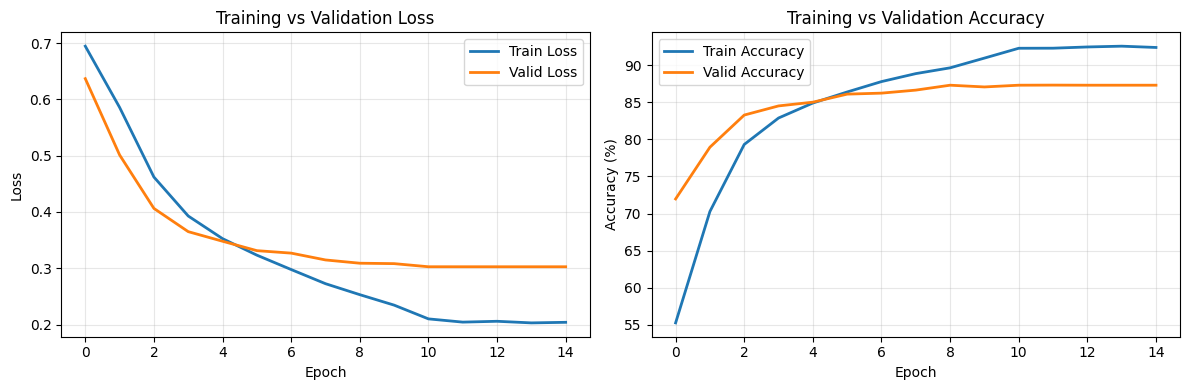

In [28]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Train Loss', linewidth=2)
plt.plot(valid_losses, label='Valid Loss', linewidth=2)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot([acc * 100 for acc in train_accs], label='Train Accuracy', linewidth=2)
plt.plot([acc * 100 for acc in valid_accs], label='Valid Accuracy', linewidth=2)
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.title('Training vs Validation Accuracy')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

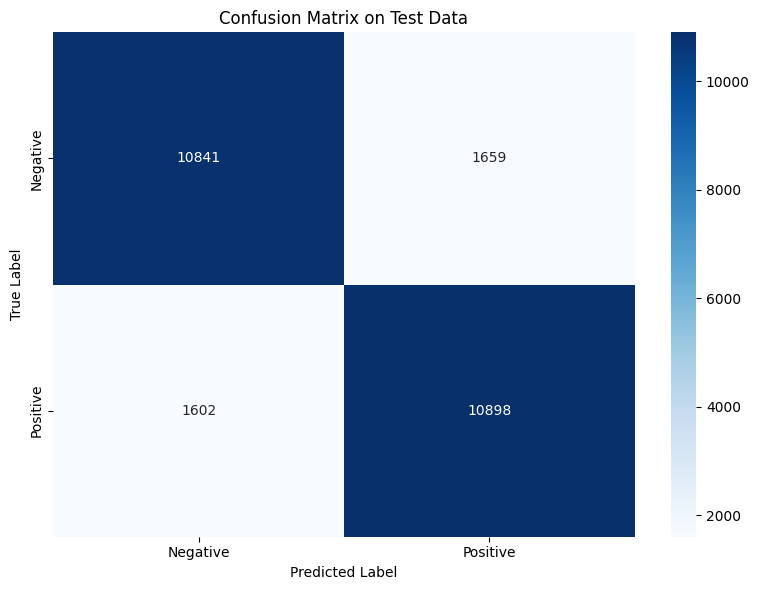

In [29]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(test_labels, test_preds)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Negative', 'Positive'], yticklabels=['Negative', 'Positive'])
plt.title('Confusion Matrix on Test Data')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()

In [30]:
def batch_predict(model, texts: List[str], vocab=vocab, tokenize_fn=tokenize, device=device):
    """Predict sentiments for a batch of texts."""
    results = []
    
    for text in texts:
        sentiment, confidence, probs = predict(model, text, vocab=vocab, tokenize_fn=tokenize_fn, device=device)
        results.append({
            'text': text[:100] + '...' if len(text) > 100 else text,
            'sentiment': sentiment,
            'confidence': f'{confidence * 100:.2f}%'
        })
    
    return results

# Model Export

In [31]:
export_dir = './sentiment_model_export'
os.makedirs(export_dir, exist_ok=True)
torch.save(model.state_dict(), os.path.join(export_dir, 'model_weights.pth'))
config = {
    'vocab_size': VOCAB_SIZE,
    'n_classes': N_CLASSES,
    'embed_dim': EMBED_DIM,
    'filter_sizes': FILTER_SIZES,
    'n_filters': N_FILTERS,
    'dropout_rate': DROPOUT_RATE,
    'pad_idx': PAD_IDX
}

with open(os.path.join(export_dir, 'config.json'), 'w') as f:
    json.dump(config, f, indent=4)

print(f'Model exported to {export_dir}/')
print(f'Files saved: model_weights.pth, config.json, tokenizer/')

Model exported to ./sentiment_model_export/
Files saved: model_weights.pth, config.json, tokenizer/


In [32]:
label_counts = Counter(test_labels)
majority_label = max(label_counts, key=label_counts.get)
baseline_accuracy = label_counts[majority_label] / sum(label_counts.values())

print('\n Model Performance Summary')
print(f'\nBaseline Accuracy (Always predicting majority class): {baseline_accuracy * 100:.2f}%')
print(f'CNN Model Accuracy: {test_acc * 100:.2f}%')
print(f'Improvement over baseline: {(test_acc - baseline_accuracy) * 100:.2f}%')
print(f'\nBest validation accuracy achieved: {best_acc * 100:.2f}%')
print(f'Test Loss: {test_loss:.4f}')
print('\n')


 Model Performance Summary

Baseline Accuracy (Always predicting majority class): 50.00%
CNN Model Accuracy: 86.96%
Improvement over baseline: 36.96%

Best validation accuracy achieved: 87.30%
Test Loss: 0.3019





: The Input Sentence as a Matrix
Shape: torch.Size([1, 5, 6]) (1 Batch, 5 Embedding Rows, 6 Words)

STEP 2 (Filter Size 2): Convolution Applied
Original Length: 6 words
New Length: 5 (Because the window slides and stops at the end)
Shape: torch.Size([1, 3, 5]) (1 Batch, 3 Filters, 5 Positions)

STEP 2 (Filter Size 3): Convolution Applied
Original Length: 6 words
New Length: 4 (Because the window slides and stops at the end)
Shape: torch.Size([1, 3, 4]) (1 Batch, 3 Filters, 4 Positions)

STEP 3: Concatenation
We stick the results together. Shape: torch.Size([1, 6])


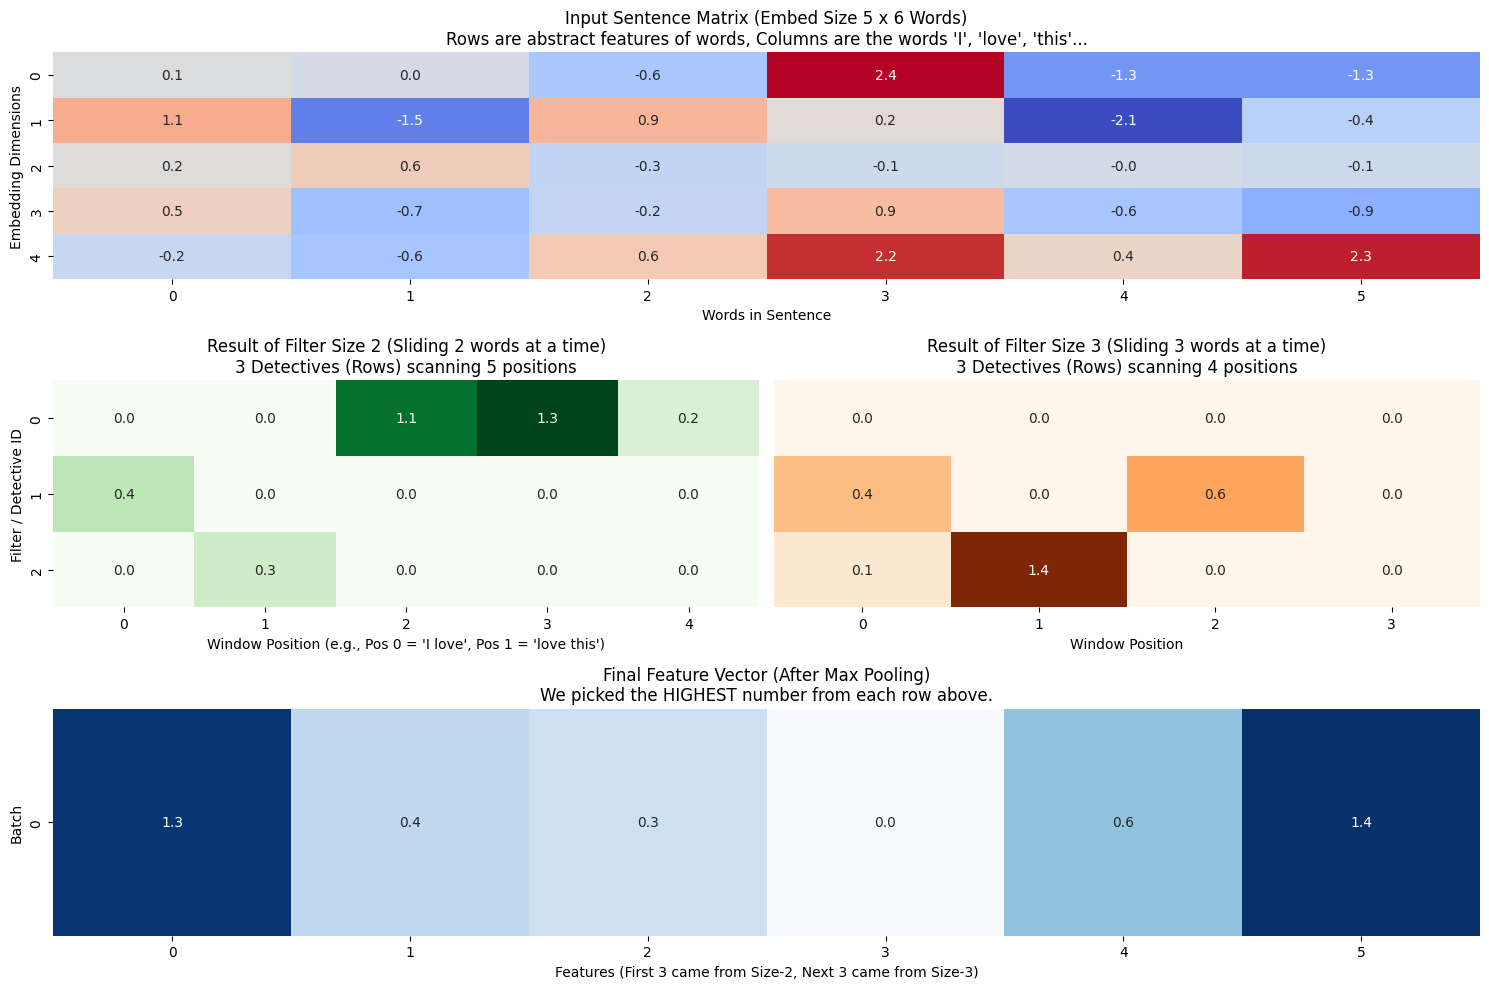

In [33]:
sentence = ["I", "love", "this", "movie", "very", "much"]
vocab = {word: i for i, word in enumerate(sentence)}
input_indices = torch.tensor([vocab[w] for w in sentence]).unsqueeze(0)

EMBED_SIZE = 5
NUM_FILTERS = 3
FILTER_SIZES = [2, 3]

class VisualizableCNN(nn.Module):
    def __init__(self):
        super(VisualizableCNN, self).__init__()
        self.embedding = nn.Embedding(len(vocab), EMBED_SIZE)
        self.convs = nn.ModuleList([
            nn.Conv1d(in_channels=EMBED_SIZE, 
                     out_channels=NUM_FILTERS, 
                     kernel_size=fs)
            for fs in FILTER_SIZES
        ])
        self.fc = nn.Linear(len(FILTER_SIZES) * NUM_FILTERS, 2)

    def forward(self, x):
        embedded = self.embedding(x) 
        embedded_permuted = embedded.permute(0, 2, 1)
        
        print(f"\n: The Input Sentence as a Matrix")
        print(f"Shape: {embedded_permuted.shape} (1 Batch, 5 Embedding Rows, 6 Words)")
        feature_maps = []
        
        conved_results = []
        
        for i, conv in enumerate(self.convs):
            conved = conv(embedded_permuted)
            
            activated = F.relu(conved)
            
            print(f"\nSTEP 2 (Filter Size {FILTER_SIZES[i]}): Convolution Applied")
            print(f"Original Length: 6 words")
            print(f"New Length: {activated.shape[2]} (Because the window slides and stops at the end)")
            print(f"Shape: {activated.shape} (1 Batch, {NUM_FILTERS} Filters, {activated.shape[2]} Positions)")
            
            feature_maps.append(activated.detach().squeeze(0).numpy())
            
            pooled = F.max_pool1d(activated, kernel_size=activated.shape[2]).squeeze(2)
            conved_results.append(pooled)
            
        cat = torch.cat(conved_results, dim=1)
        print(f"\nSTEP 3: Concatenation")
        print(f"We stick the results together. Shape: {cat.shape}")
        
        return cat, feature_maps, embedded_permuted
model = VisualizableCNN()
output_vector, feature_maps, input_matrix = model(input_indices)
plt.figure(figsize=(15, 10))
plt.subplot(3, 1, 1)
sns.heatmap(input_matrix.detach().squeeze(0).numpy(), annot=True, fmt=".1f", cmap="coolwarm", cbar=False)
plt.title(f"Input Sentence Matrix (Embed Size {EMBED_SIZE} x 6 Words)\nRows are abstract features of words, Columns are the words 'I', 'love', 'this'...")
plt.xlabel("Words in Sentence")
plt.ylabel("Embedding Dimensions")
plt.subplot(3, 2, 3)
sns.heatmap(feature_maps[0], annot=True, fmt=".1f", cmap="Greens", cbar=False)
plt.title(f"Result of Filter Size 2 (Sliding 2 words at a time)\n3 Detectives (Rows) scanning 5 positions")
plt.xlabel("Window Position (e.g., Pos 0 = 'I love', Pos 1 = 'love this')")
plt.ylabel("Filter / Detective ID")
plt.subplot(3, 2, 4)
sns.heatmap(feature_maps[1], annot=True, fmt=".1f", cmap="Oranges", cbar=False)
plt.title(f"Result of Filter Size 3 (Sliding 3 words at a time)\n3 Detectives (Rows) scanning 4 positions")
plt.xlabel("Window Position")
plt.yticks([])
plt.subplot(3, 1, 3)
final_vector = output_vector.detach().numpy()
sns.heatmap(final_vector, annot=True, fmt=".1f", cmap="Blues", cbar=False)
plt.title(f"Final Feature Vector (After Max Pooling)\nWe picked the HIGHEST number from each row above.")
plt.xlabel("Features (First 3 came from Size-2, Next 3 came from Size-3)")
plt.ylabel("Batch")

plt.tight_layout()
plt.show()

## References

1. [Convolutional Neural Networks for Sentence Classification](https://arxiv.org/pdf/1408.5882.pdf)
2. [A Sensitivity Analysis of (and Practitioners’ Guide to) Convolutional Neural Networks for Sentence Classification](https://arxiv.org/pdf/1510.03820.pdf)
3. [Official Theano Implementation by Yoon Kim](https://github.com/yoonkim/CNN_sentence)
4. [PyTorch Sentiment Analysis by Ben Trevet](https://github.com/bentrevett/pytorch-sentiment-analysis)
